# Data sourcing & pre-processing

Notebook for **DSA4265** — how we pull prices, poke around the data, clean things up, and dump CSVs for the quant bit, agent tools, and the Streamlit UI.

**What I'm doing here**

- Pull prices with `yfinance` (same tickers + date range each time so results are reproducible).
- Quick EDA: shape, missing dates, basic stats.
- Charts so we can eyeball whether anything looks broken.
- Cleaning steps + why we bother (returns, vol, VaR, etc.).
- Save everything under `data/processed/` so the rest of the group can just `read_csv` without drama.


## 1. Why this data

We're building a portfolio-style chatbot thing: user gives tickers + weights, we spit out risk-ish numbers, maybe ML, maybe RAG text. For that you need **daily prices lined up on the same calendar** for every ticker.

Roughly:

- Portfolio return = weighted sum of **same-day** asset returns → dates must match.
- Vol, VaR, drawdown, Sharpe, correlation → work on **returns**, not raw prices.
- ML side (NN / LSTM) needs clean return series and rolling windows (e.g. 60 days).
- If the agent loads CSVs, everyone should agree on column names and date index.

**Data source:** Yahoo Finance through `yfinance`. Free, no API key, good enough for a course project if you say what sucks about it later. Tickers match what we agreed as a group:

| Ticker | Rough role |
|--------|------------|
| AAPL, MSFT, TSLA | Stocks (tech / growth-y) |
| SPY | Broad US equity |
| TLT | Long bonds (rates matter) |
| GLD | Gold |

Mix of stuff so correlation / diversification isn't totally boring.


## 2. Imports + where files go


In [1]:
from __future__ import annotations

import json
from pathlib import Path

from IPython.display import display

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# run from repo root so paths work
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("Output dir:", DATA_DIR.resolve())


PROJECT_ROOT: /Users/jingyan/Desktop/y4s2/dsa4265/grp_project
Output dir: /Users/jingyan/Desktop/y4s2/dsa4265/grp_project/data/processed


### Date range — pick one and stick with it

Everyone (RAG, ML, UI) should use the **same** start/end or you'll argue about numbers for no reason.

- **Lazy default:** last ~5 years up to whenever you run this — fine for "current" portfolio vibes.
- **Frozen window:** e.g. `2018-01-01` to `2023-01-01` if you want a closed period for the writeup.

Tweak `START` / `END` in the next cell once, rerun the notebook.


In [2]:
# tweak these and rerun
START = "2020-01-01"
END = None  # None = up to today; or pin e.g. "2025-03-01" for a snapshot

TICKERS = ["AAPL", "MSFT", "TSLA", "SPY", "TLT", "GLD"]

meta = {
    "tickers": TICKERS,
    "start": START,
    "end": str(END) if END is not None else "today",
    "source": "yfinance (Yahoo Finance)",
    "price_field": "Adj Close",
    "notes": "Adj Close so splits/dividends don't wreck returns",
}
print(json.dumps(meta, indent=2))


{
  "tickers": [
    "AAPL",
    "MSFT",
    "TSLA",
    "SPY",
    "TLT",
    "GLD"
  ],
  "start": "2020-01-01",
  "end": "today",
  "source": "yfinance (Yahoo Finance)",
  "price_field": "Adj Close",
  "notes": "Adj Close so splits/dividends don't wreck returns"
}


## 3. Download prices

Using **Adj Close** (not raw close) so splits/dividends don't fake huge jumps. `yfinance` output shape varies by version; next cell squashes it into a simple date index × tickers table.


In [3]:
def download_adj_close(tickers: list[str], start: str, end: str | None) -> pd.DataFrame:
    # grab Adj Close only; yfinance returns MultiIndex mess depending on version
    df = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        threads=True,
    )
    if df.empty:
        raise RuntimeError("No data — bad tickers, bad dates, or no internet?")

    if isinstance(df.columns, pd.MultiIndex):
        if "Adj Close" in df.columns.get_level_values(0):
            out = df["Adj Close"].copy()
        else:
            out = df.xs("Adj Close", axis=1, level=0, drop_level=True)
            if isinstance(out, pd.Series):
                out = out.to_frame(name=tickers[0])
    else:
        out = df.rename(columns={"Adj Close": tickers[0]})

    out = out.sort_index()
    out.index = pd.to_datetime(out.index).tz_localize(None)
    out = out[tickers]
    return out


raw_prices = download_adj_close(TICKERS, START, END)
raw_prices.head()


Ticker,AAPL,MSFT,TSLA,SPY,TLT,GLD
Date,,,,,,
2020-01-02,72.400536,152.158386,28.684000,296.888184,114.622665,143.949997
2020-01-03,71.696648,150.263779,29.534000,294.640076,116.387932,145.860001
2020-01-06,72.267921,150.652145,30.102667,295.764130,115.727005,147.389999
2020-01-07,71.928040,149.278549,31.270666,294.932465,115.158104,147.970001
2020-01-08,73.085106,151.656342,32.809334,296.504364,114.396751,146.860001


## 4. Quick EDA before cleaning

Skim: date range, missing %, duplicate dates. If something looks cursed we fix it in the cleaning section and mention it in the report.


In [4]:
def eda_summary(prices: pd.DataFrame) -> None:
    print("Shape (days × assets):", prices.shape)
    print("Date range:", prices.index.min().date(), "→", prices.index.max().date())
    print()
    print("dtypes:")
    print(prices.dtypes)
    dup_dates = prices.index.duplicated().sum()
    print()
    print("Duplicate dates:", int(dup_dates))
    print()
    print("Missing % per ticker:")
    print((prices.isna().mean() * 100).round(2))
    print()
    print("Descriptive stats (levels):")
    display(prices.describe().T)


eda_summary(raw_prices)


Shape (days × assets): (1567, 6)
Date range: 2020-01-02 → 2026-03-27

dtypes:
Ticker
AAPL    float64
MSFT    float64
TSLA    float64
SPY     float64
TLT     float64
GLD     float64
dtype: object

Duplicate dates: 0

Missing % per ticker:
Ticker
AAPL    0.0
MSFT    0.0
TSLA    0.0
SPY     0.0
TLT     0.0
GLD     0.0
dtype: float64

Descriptive stats (levels):


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,1567.0,168.390726,52.048852,54.213600,133.043167,166.266846,207.465607,285.922455
MSFT,1567.0,319.353469,101.229967,128.636322,237.061447,300.737701,408.248627,539.825195
TSLA,1567.0,243.867855,101.288113,24.081333,185.029999,238.210007,303.288330,489.880005
SPY,1567.0,448.700935,116.041116,204.944885,370.487625,419.013336,542.939972,693.595764
TLT,1567.0,103.049950,20.179445,74.837929,86.519871,92.348846,122.746628,144.897552
GLD,1567.0,212.828985,74.012756,138.039993,168.125000,179.500000,232.300003,495.899994


## 5. Charts

Normalise to 100 at the start so you can compare expensive vs cheap stocks on one plot. Then drawdown + rolling vol below — useful for the writeup.

**Drawdown / rolling vol** — next bit; ties to max drawdown and "how risky was it lately" stuff.


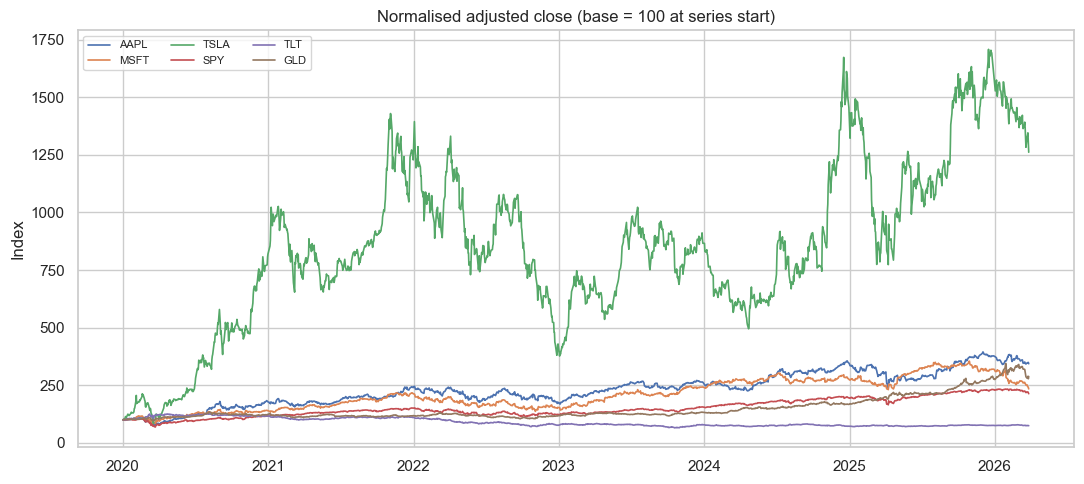

In [5]:
def normalise_to_base100(px: pd.DataFrame) -> pd.DataFrame:
    return px.divide(px.iloc[0]).mul(100)


norm_px = normalise_to_base100(raw_prices)

fig, ax = plt.subplots(figsize=(11, 5))
for col in norm_px.columns:
    ax.plot(norm_px.index, norm_px[col], label=col, linewidth=1.2)
ax.set_title("Normalised adjusted close (base = 100 at series start)")
ax.set_ylabel("Index")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


### Drawdown + rolling vol (quick definitions)

**Drawdown** — how far below the **running high** we are: (today / max so far) − 1. Values are ≤ 0; the worst point is the max drawdown story for that line.

**Rolling vol** — stdev of daily returns over the last *w* days, then × √252 to annualise. Using simple returns. Here *w* = 21 (~1 month) and 60 (same ballpark as the LSTM window the quant side talked about).


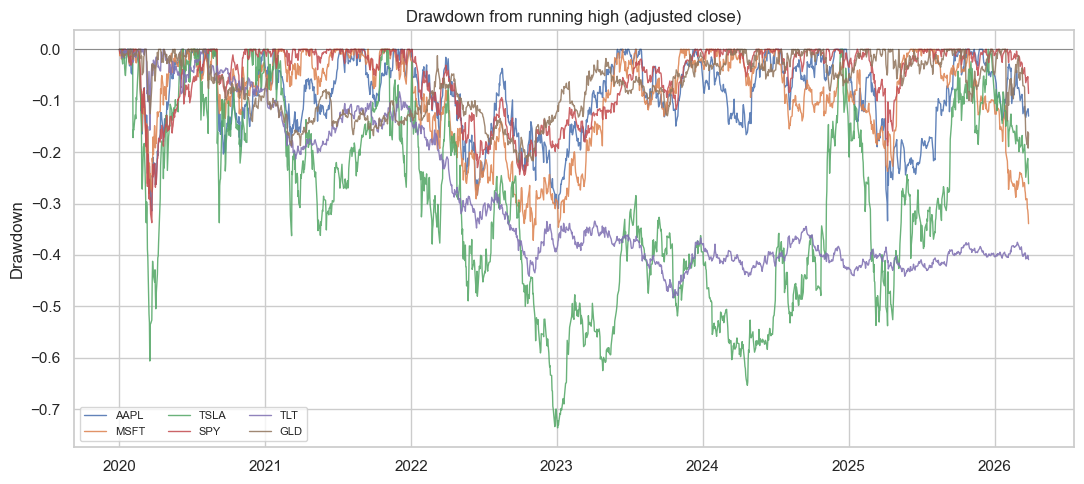

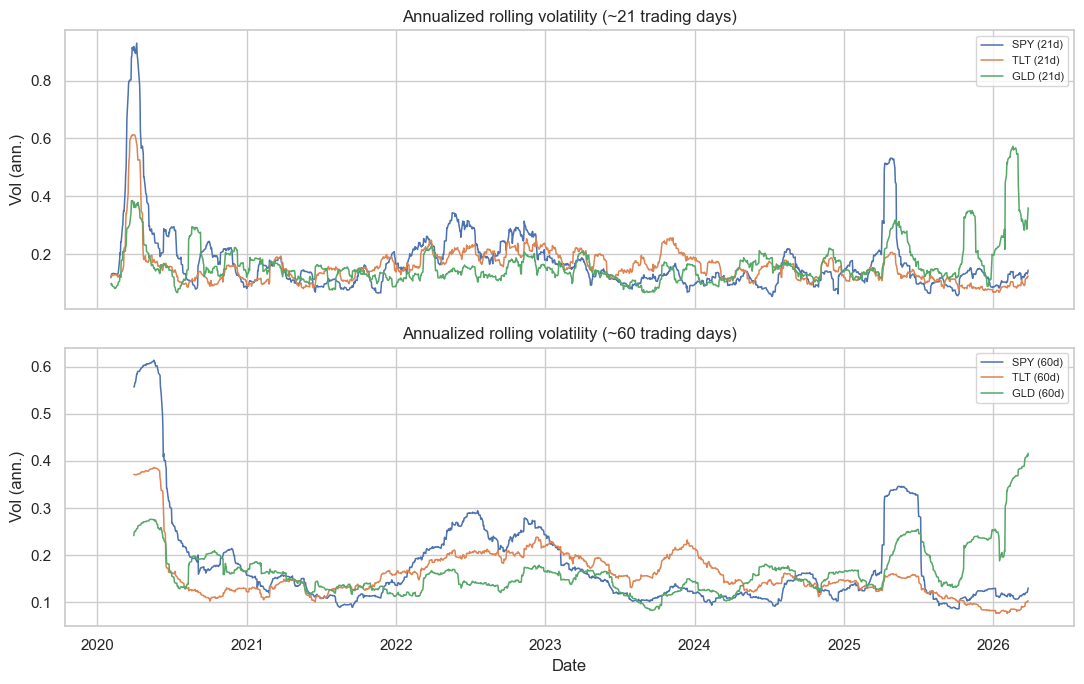

In [6]:
TRADING_DAYS_PER_YEAR = 252
ROLL_SHORT = 21
ROLL_LONG = 60  # same order of magnitude as LSTM window


def price_drawdown(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.div(prices.cummax()).sub(1.0)


dd = price_drawdown(raw_prices)

fig, ax = plt.subplots(figsize=(11, 5))
for col in dd.columns:
    ax.plot(dd.index, dd[col], label=col, linewidth=1.0, alpha=0.88)
ax.set_title("Drawdown from running high (adjusted close)")
ax.set_ylabel("Drawdown")
ax.legend(ncol=3, fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, alpha=0.45)
plt.tight_layout()
plt.show()

# annualised rolling vol from simple returns
_re = raw_prices.pct_change()
roll_vol_short = _re.rolling(ROLL_SHORT).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
roll_vol_long = _re.rolling(ROLL_LONG).std() * np.sqrt(TRADING_DAYS_PER_YEAR)

focus = ["SPY", "TLT", "GLD"]  # swap if you only care about stocks
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for name in focus:
    if name in roll_vol_short.columns:
        axes[0].plot(
            roll_vol_short.index,
            roll_vol_short[name],
            label=f"{name} ({ROLL_SHORT}d)",
            linewidth=1.1,
        )
axes[0].set_title(f"Annualized rolling volatility (~{ROLL_SHORT} trading days)")
axes[0].set_ylabel("Vol (ann.)")
axes[0].legend(fontsize=8)

for name in focus:
    if name in roll_vol_long.columns:
        axes[1].plot(
            roll_vol_long.index,
            roll_vol_long[name],
            label=f"{name} ({ROLL_LONG}d)",
            linewidth=1.1,
        )
axes[1].set_title(f"Annualized rolling volatility (~{ROLL_LONG} trading days)")
axes[1].set_ylabel("Vol (ann.)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


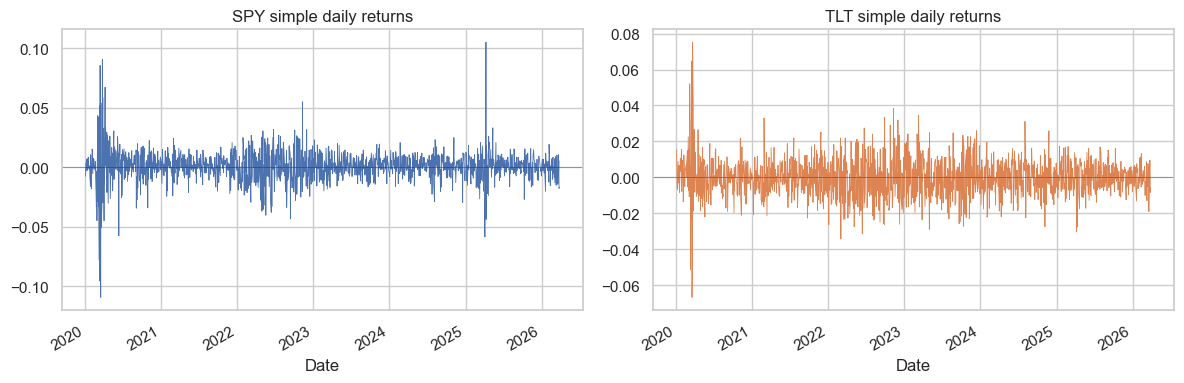

,mean,std,min,max
Ticker,,,,
AAPL,0.000986,0.019887,-0.128647,0.153288
MSFT,0.000720,0.018716,-0.147390,0.142169
TSLA,0.002472,0.041377,-0.210628,0.226900
SPY,0.000568,0.012924,-0.109424,0.105019
TLT,-0.000130,0.010647,-0.066683,0.075197
GLD,0.000740,0.011310,-0.102742,0.063587


In [7]:
simple_rets = raw_prices.pct_change()
log_rets = np.log(raw_prices).diff()  # optional; some models prefer log returns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
simple_rets["SPY"].dropna().plot(ax=axes[0], linewidth=0.6, title="SPY simple daily returns")
simple_rets["TLT"].dropna().plot(ax=axes[1], linewidth=0.6, title="TLT simple daily returns", color="C1")
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

simple_rets.describe().T[["mean", "std", "min", "max"]]


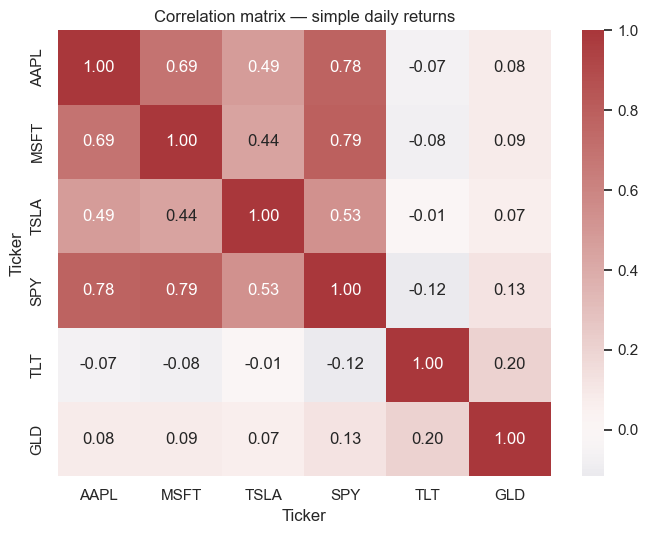

In [8]:
corr = simple_rets.dropna().corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation matrix — simple daily returns")
plt.tight_layout()
plt.show()


## 6. Cleaning — what we actually do

| Step | What | Why |
|------|------|-----|
| Sort index | oldest → newest | rolling stuff breaks if dates are scrambled |
| Missing | ffill a few days max, then drop rows with any NA | calendars don't line up perfectly; don't ffill forever or you fake data |
| Returns | `pct_change()` / `log().diff()` | risk metrics want returns, not price levels |
| Align | drop rows until **all** tickers have a price | portfolio math needs same date for every column |
| Winsorise? | clip extreme days if you really want | only if you see obvious bad ticks — say so in the report |

**Group stuff:** everyone should use the same return definition (simple vs log) and same window length for ML so "vol" means the same thing in the app and here.


In [9]:
def clean_prices(prices: pd.DataFrame, ffill_limit: int = 5) -> pd.DataFrame:
    px = prices.sort_index()
    px = px.ffill(limit=ffill_limit)
    px = px.dropna(how="any")
    return px


prices_clean = clean_prices(raw_prices)
print("Rows raw vs clean:", len(raw_prices), "→", len(prices_clean))
print("Remaining NA:", int(prices_clean.isna().sum().sum()))

simple_rets_clean = prices_clean.pct_change().dropna()
log_rets_clean = np.log(prices_clean).diff().dropna()

print("Return rows:", len(simple_rets_clean))
simple_rets_clean.head()


Rows raw vs clean: 1567 → 1567
Remaining NA: 0
Return rows: 1566


Ticker,AAPL,MSFT,TSLA,SPY,TLT,GLD
Date,,,,,,
2020-01-03,-0.009722,-0.012452,0.029633,-0.007572,0.015401,0.013269
2020-01-06,0.007968,0.002585,0.019255,0.003815,-0.005679,0.010490
2020-01-07,-0.004703,-0.009118,0.038801,-0.002812,-0.004916,0.003935
2020-01-08,0.016086,0.015929,0.049205,0.005330,-0.006611,-0.007502
2020-01-09,0.021241,0.012493,-0.021945,0.006781,0.003511,-0.005652


### Portfolio returns (same logic as the UI)

User picks weights that sum to 1 (or 100%). Each day:

`portfolio return = sum of (weight × that asset's return)` for that day.

Example: 40% SPY, 60% TLT → `0.4 × r_SPY + 0.6 × r_TLT`.

After tickers are validated, Streamlit should compute this series the same way before feeding vol / VaR / Sharpe.


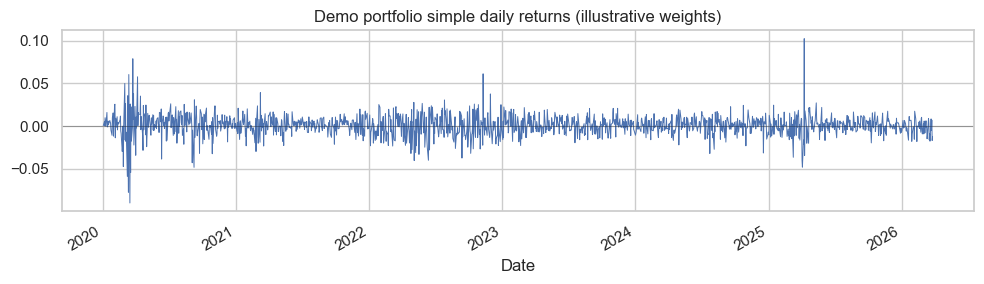

Cumulative growth of $1 (demo): 2.897679128815097


In [10]:
# made-up weights for demo — same order as TICKERS
weights = np.array([0.15, 0.15, 0.10, 0.35, 0.15, 0.10])
assert np.isclose(weights.sum(), 1.0)
assert len(weights) == len(TICKERS)

port_ret = simple_rets_clean.mul(weights, axis=1).sum(axis=1)
port_ret.name = "portfolio"

fig, ax = plt.subplots(figsize=(10, 3))
port_ret.plot(ax=ax, linewidth=0.7)
ax.set_title("Demo portfolio simple daily returns (illustrative weights)")
ax.axhline(0, color="black", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

cumulative = (1 + port_ret).cumprod()
print("Cumulative growth of $1 (demo):", float(cumulative.iloc[-1]))


### 60-day windows (sanity check)

Quant pipeline mentioned 60-day blocks — rough count of non-overlapping chunks below. Can switch to sliding windows with stride 1 for more samples.


In [11]:
WINDOW = 60
n = len(simple_rets_clean)
n_nonoverlap = n // WINDOW
print(f"Rows in simple_rets_clean: {n}")
print(f"Non-overlapping {WINDOW}-day blocks: {n_nonoverlap} (rough count)")


Rows in simple_rets_clean: 1566
Non-overlapping 60-day blocks: 26 (rough count)


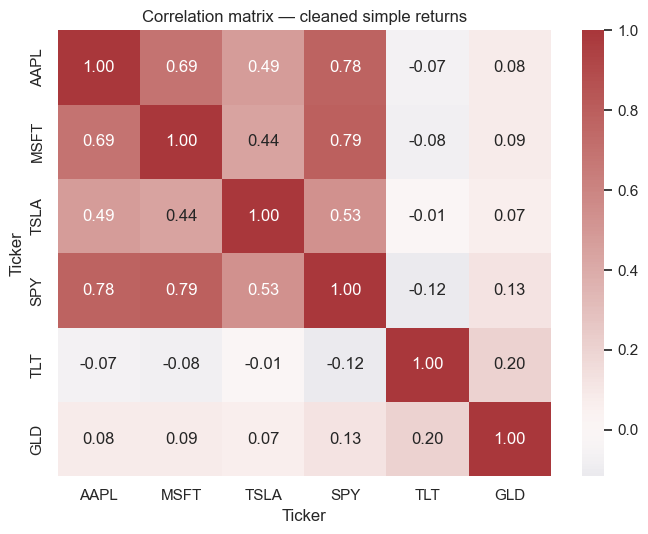

In [12]:
# correlation after cleaning — use this one for the report if you only show one heatmap
corr_clean = simple_rets_clean.corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation matrix — cleaned simple returns")
plt.tight_layout()
plt.show()


## 7. Save to disk

Writes:

- `adj_close_prices.csv` — cleaned levels  
- `simple_returns.csv` / `log_returns.csv`  
- `dataset_meta.json` — tickers, dates, row counts (so we remember what we ran)


In [13]:
prices_clean.to_csv(DATA_DIR / "adj_close_prices.csv")
simple_rets_clean.to_csv(DATA_DIR / "simple_returns.csv")
log_rets_clean.to_csv(DATA_DIR / "log_returns.csv")

export_meta = {
    **meta,
    "rows_prices_clean": int(len(prices_clean)),
    "rows_returns": int(len(simple_rets_clean)),
    "ffill_limit": 5,
    "cleaning": "sort_index → ffill(limit=5) → dropna(how='any')",
    "files": [
        "adj_close_prices.csv",
        "simple_returns.csv",
        "log_returns.csv",
    ],
}
(DATA_DIR / "dataset_meta.json").write_text(json.dumps(export_meta, indent=2), encoding="utf-8")

print("Wrote:", [p.name for p in DATA_DIR.iterdir()])


Wrote: ['log_returns.csv', 'adj_close_prices.csv', 'dataset_meta.json', 'simple_returns.csv']


## 8. Caveats (worth mentioning in the report)

- Yahoo isn't Bloomberg; splits can get revised sometimes.
- Six tickers ≠ "the whole market" — don't oversell the universe.
- Daily close ≠ price you can trade at every second; VaR is a model, not a promise.
- RAG docs vs market data: separate "facts from filings" vs "prices from here" so you don't mix sources sloppily.

**Before you hand in**

- [ ] same start/end as ML + agent + UI  
- [ ] agree simple vs log returns with quant  
- [ ] Streamlit reads `data/processed/` or imports shared helpers  
- [ ] rerun notebook once before submission so CSVs match the plots  
